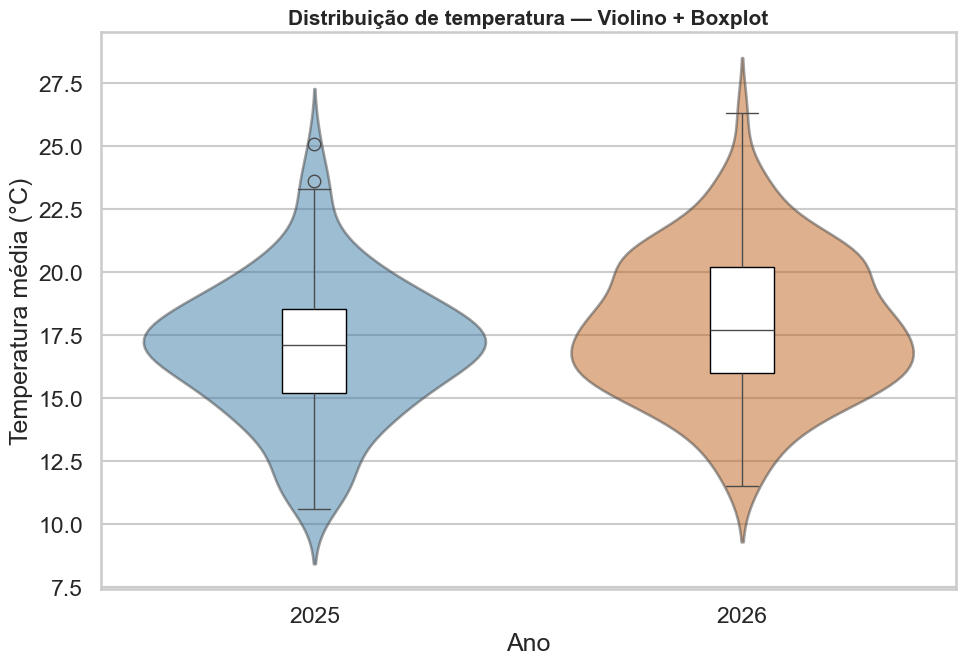

In [2]:
# P2-A: Violino + Boxplot
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
a["ano_ref"], b["ano_ref"] = "2025", "2026"
df = pd.concat([a, b], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.violinplot(data=df, x="ano_ref", y="Temperatura_media", hue="ano_ref",
                palette=[COR_2025, COR_2026], ax=ax, inner=None, legend=False, alpha=0.5)
sns.boxplot(data=df, x="ano_ref", y="Temperatura_media", width=0.15,
            boxprops=dict(facecolor="white", edgecolor="black"), ax=ax)
ax.set_title("Distribuição de temperatura — Violino + Boxplot", fontsize=15, fontweight="bold")
ax.set_xlabel("Ano"); ax.set_ylabel("Temperatura média (°C)")
plt.tight_layout()
plt.savefig("p2_a_violino.png", dpi=150)

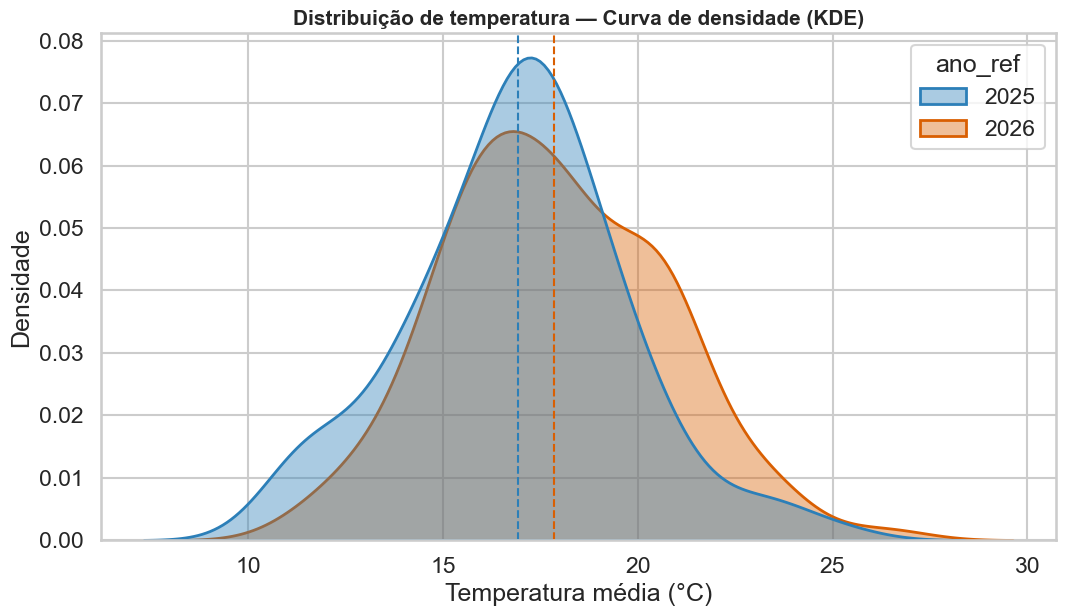

In [1]:
# P2-B: Curva de densidade (KDE)
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
a["ano_ref"], b["ano_ref"] = "2025", "2026"
df = pd.concat([a, b], ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.kdeplot(data=df, x="Temperatura_media", hue="ano_ref", fill=True,
            palette={"2025": COR_2025, "2026": COR_2026}, alpha=0.4, linewidth=2, ax=ax)
for ano, cor in [("2025", COR_2025), ("2026", COR_2026)]:
    media = df[df["ano_ref"] == ano]["Temperatura_media"].mean()
    ax.axvline(media, color=cor, linestyle="--", linewidth=1.5)
ax.set_title("Distribuição de temperatura — Curva de densidade (KDE)", fontsize=15, fontweight="bold")
ax.set_xlabel("Temperatura média (°C)"); ax.set_ylabel("Densidade")
plt.tight_layout()
plt.savefig("p2_b_kde.png", dpi=150)

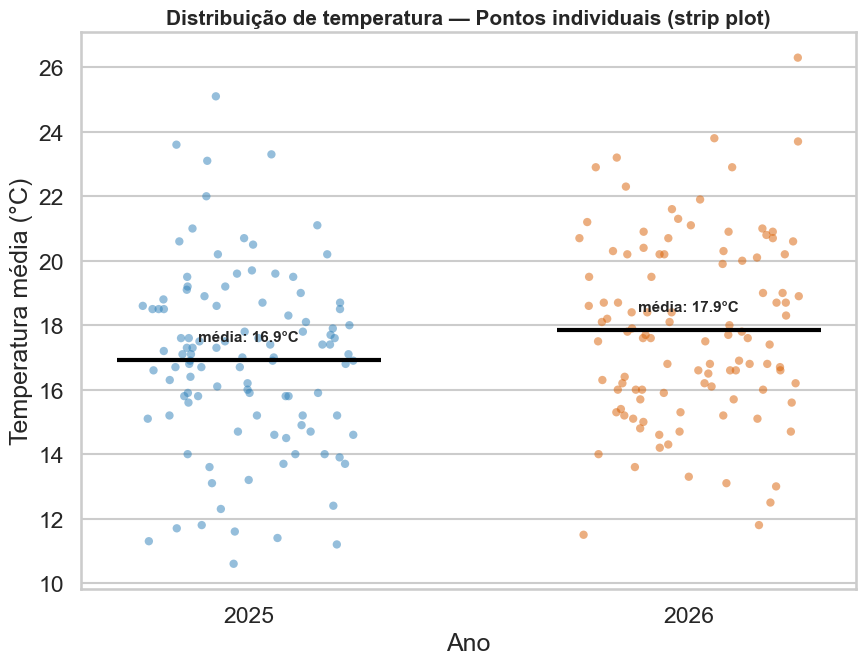

In [3]:
# P2-C: Pontos individuais (strip plot)
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
COR_2025, COR_2026 = "#2C7FB8", "#D95F02"
a = pd.read_csv("data/gold/ddm_clima_sp_2025-06-01_2025-09-15.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-15.csv", parse_dates=["Data"])
a["ano_ref"], b["ano_ref"] = "2025", "2026"
df = pd.concat([a, b], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.stripplot(data=df, x="ano_ref", y="Temperatura_media", hue="ano_ref",
              palette=[COR_2025, COR_2026], alpha=0.5, size=6, jitter=0.25, legend=False, ax=ax)
for i, ano in enumerate(["2025", "2026"]):
    media = df[df["ano_ref"] == ano]["Temperatura_media"].mean()
    ax.hlines(media, i - 0.3, i + 0.3, color="black", linewidth=3, zorder=5)
    ax.text(i, media + 0.6, f"média: {media:.1f}°C", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Distribuição de temperatura — Pontos individuais (strip plot)", fontsize=15, fontweight="bold")
ax.set_xlabel("Ano"); ax.set_ylabel("Temperatura média (°C)")
plt.tight_layout()
plt.savefig("p2_c_stripplot.png", dpi=150)